In [1]:
import warnings
from copy import deepcopy

import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2

from src import (
    models,
    dataset,
    metrics,
    plotting,
)
from src import configs as cfg

/root/repos/raidium_challenge/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
chkpt_pth = "./unet_epoch_1750.pt"

In [3]:
chkpt = torch.load(chkpt_pth, weights_only=False)
train_cfg = cfg.TrainingConfig(**chkpt["train_cfg"])
data_loaders = dataset.mk_segmentation_data_loaders(train_cfg)
model_cfg = cfg.ModelConfig(**chkpt["model_cfg"])
model = models.mk_model_from_cfg(model_cfg)
model.load_state_dict(chkpt["model"])

sampling method: weighted
train_dl_kwargs: {'sampler': <torch.utils.data.sampler.WeightedRandomSampler object at 0x7fc3bcc71550>, 'batch_size': 64}


<All keys matched successfully>

<class 'torch.Tensor'>
<class 'torchvision.tv_tensors._mask.Mask'>
<class 'torchvision.tv_tensors._mask.Mask'>
cuda:0 torch.float32


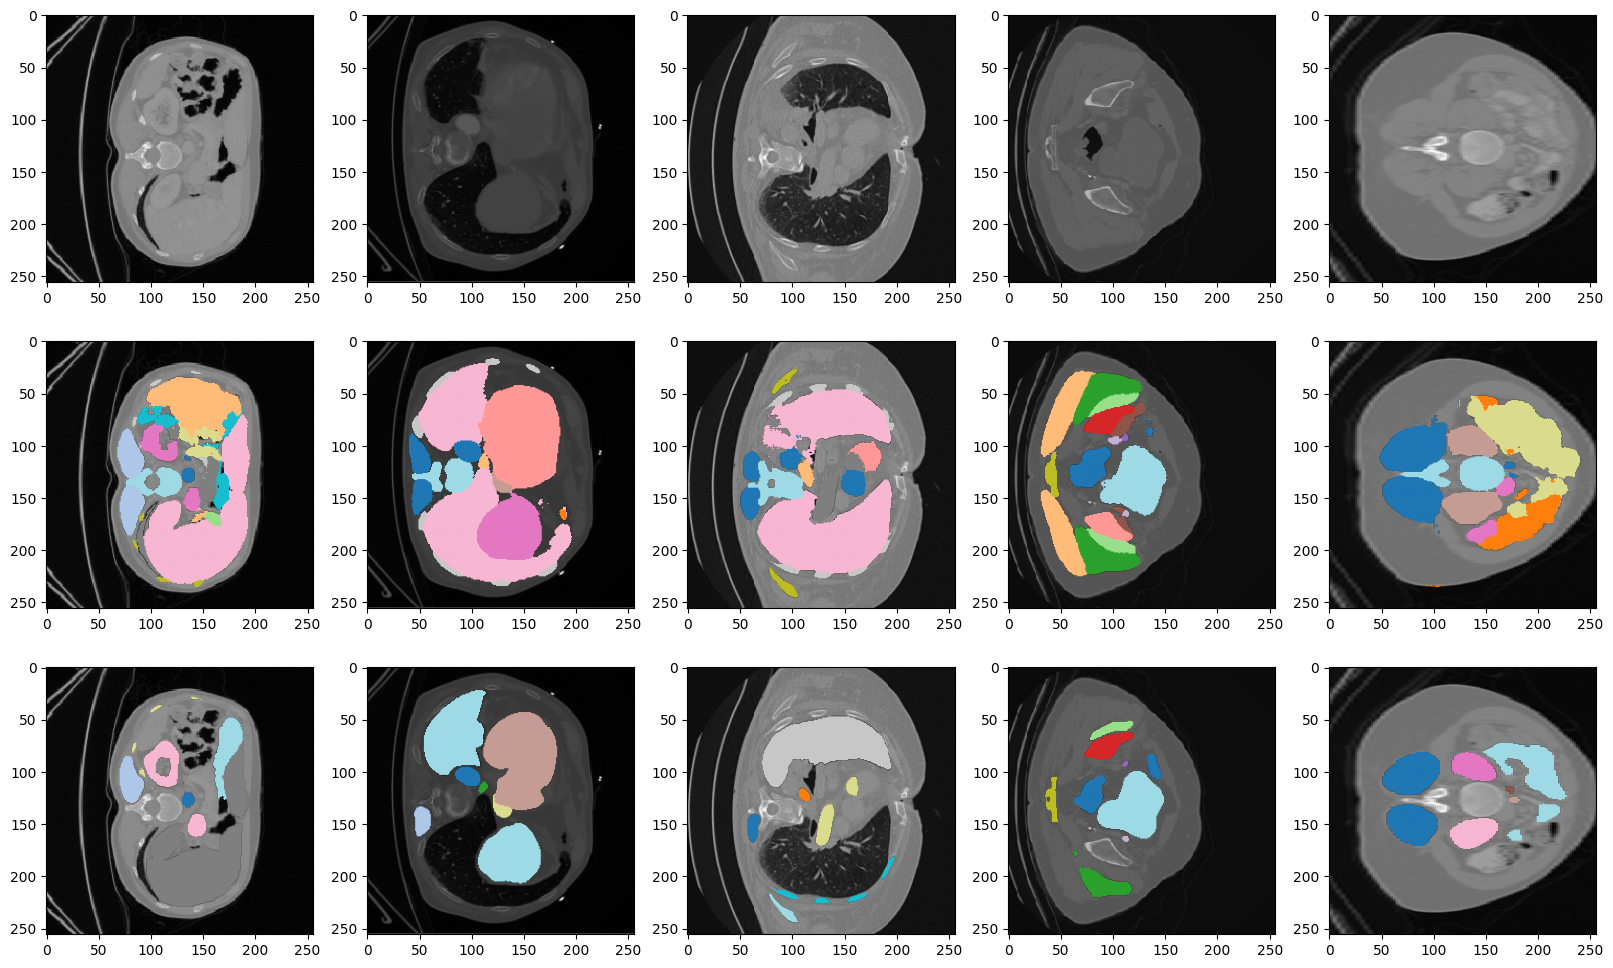

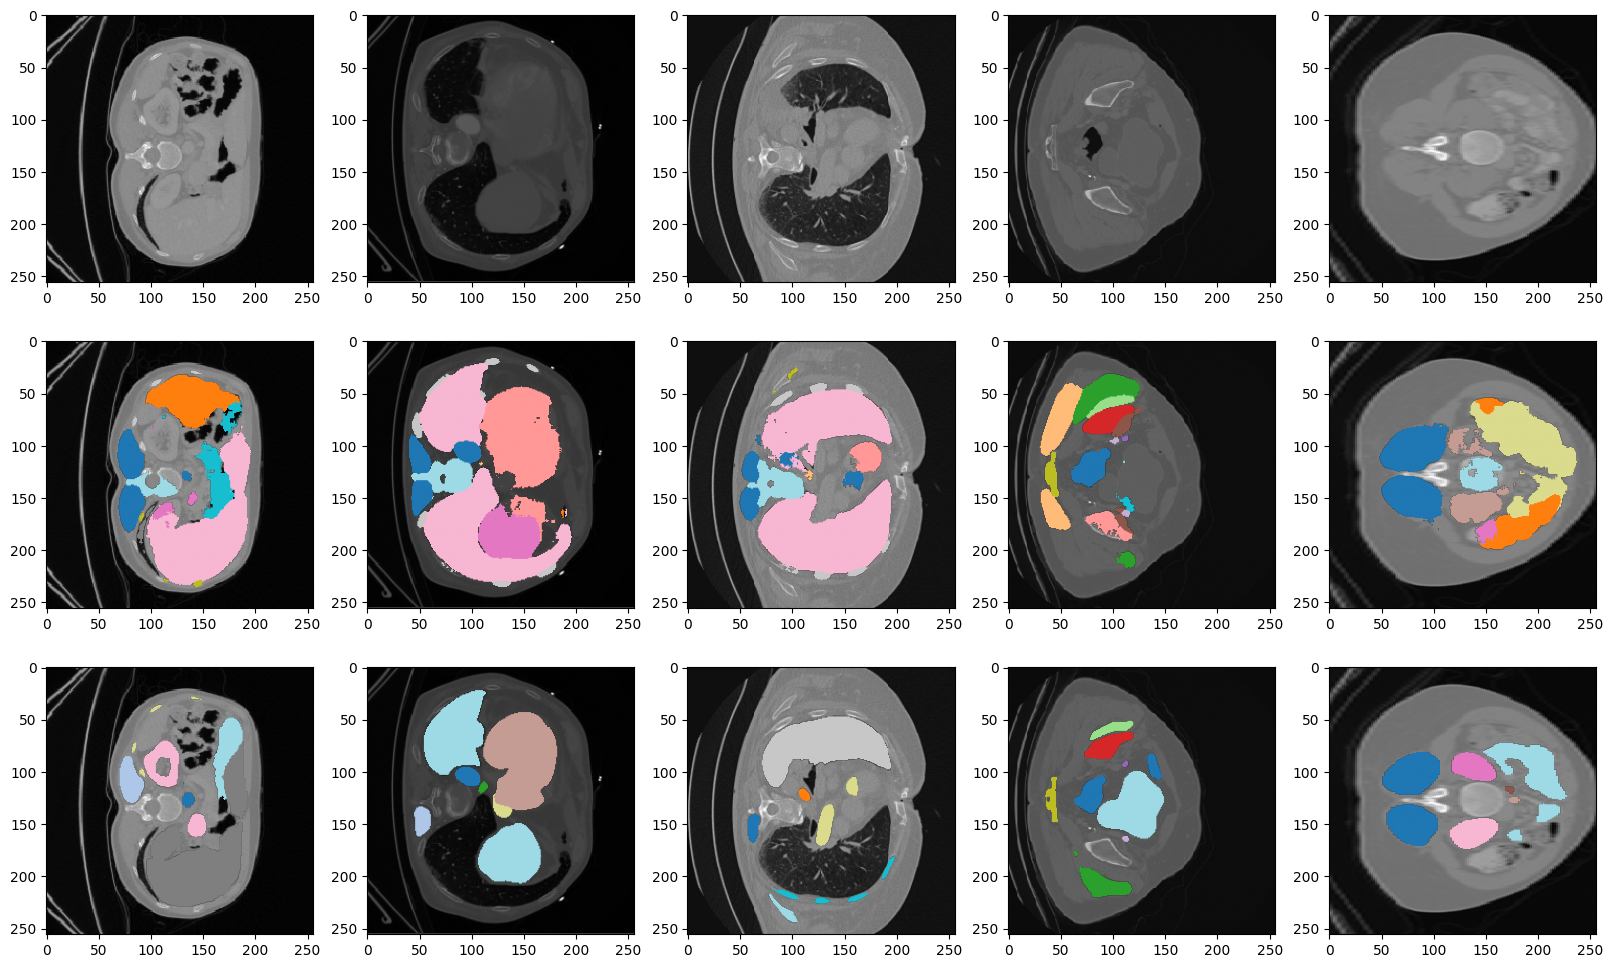

In [4]:
def plt_seg_pred(
        forward_dict: dict[str, torch.Tensor],
        ax_size: int = 4,
    ):
    forward_dict = deepcopy(forward_dict)
    forward_dict["y_pred"] = torch.argmax(forward_dict["y_pred"], dim=1)
    seg_masks_keys = ("y_pred", "y_true")
    n_samples_to_plt = min(len(forward_dict["x"]), plotting.MAX_N_SAMPLES_TO_PLOT)
    n_rows = 3
    forward_dict["x"] = forward_dict["x"].detach().cpu().numpy().squeeze()
    forward_dict["y_pred"] = forward_dict["y_pred"].detach().cpu().numpy()
    forward_dict["y_true"] = forward_dict["y_true"].detach().cpu().numpy()
    fig, axes = plt.subplots(n_rows, n_samples_to_plt, squeeze=False)
    fig.set_size_inches(n_samples_to_plt * ax_size, n_rows * ax_size)
    for seg_mask_key in seg_masks_keys:
        forward_dict[seg_mask_key] = forward_dict[seg_mask_key][:n_samples_to_plt]
    for j in range(n_samples_to_plt):
        axes[0, j].imshow(
            forward_dict["x"][j],
            cmap="gray",
        )
        plotting.imshow_seg(axes[1, j], forward_dict["x"][j], forward_dict["y_pred"][j])
        plotting.imshow_seg(axes[2, j], forward_dict["x"][j], forward_dict["y_true"][j])


tta_transforms = v2.Compose([
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1)),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1)),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1), value="random"),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1), value="random"),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1), value="random"),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1), value="random"),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1), value="random"),
    v2.RandomErasing(p=0.2, scale=(0.05, 0.1), value="random"),
    v2.RandomApply(torch.nn.ModuleList([v2.GaussianBlur(9, sigma=5)])),
])
N_AUGS = 3

warnings.filterwarnings(
    "ignore",
    message="RandomErasing.*tv_tensors.Mask",
    category=UserWarning,
)
with torch.no_grad():
    model.eval()
    x, y_true = next(iter(data_loaders["valid"]))
    print(type(y_true))
    forward_dict = dataset.preprocess_batch({"x": x, "y_true": y_true})
    print(type(forward_dict["y_true"]))
    forward_dict |= model(forward_dict)
    plt_seg_pred(forward_dict)
    print(type(forward_dict["y_true"]))
    tta_pred = torch.zeros_like(forward_dict["y_pred"])
    print(tta_pred.device, tta_pred.dtype)
    for _ in range(N_AUGS):
        tta_batch = tta_transforms(forward_dict)
        tta_pred += model(tta_batch)["y_pred"] / N_AUGS
    plt_seg_pred({"x": x, "y_pred": tta_pred, "y_true": forward_dict["y_true"]})